In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_excel("data\Telco_customer_churn.xlsx")


In [4]:
df.sample(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
3130,6303-KFWSL,1,United States,California,Los Angeles,90071,"34.052917, -118.255178",34.052917,-118.255178,Female,...,One year,Yes,Electronic check,55.25,1620.2,No,0,55,5481,NaN
4258,2703-AMTUL,1,United States,California,Lookout,96054,"41.280478, -121.160249",41.280478,-121.160249,Male,...,One year,No,Mailed check,53.65,1939.35,No,0,37,4113,NaN
1546,4512-ZUIYL,1,United States,California,Sunnyvale,94089,"37.421633, -122.009613",37.421633,-122.009613,Female,...,Month-to-month,No,Bank transfer (automatic),70.00,153.05,Yes,1,81,2928,Moved
635,1254-IZEYF,1,United States,California,Cutler,93615,"36.497895, -119.285484",36.497895,-119.285484,Female,...,Month-to-month,Yes,Electronic check,99.95,3186.65,Yes,1,96,5362,Competitor made better offer
796,5692-FPTAH,1,United States,California,Nicolaus,95659,"38.788898, -121.608624",38.788898,-121.608624,Female,...,Month-to-month,Yes,Mailed check,45.40,45.4,Yes,1,67,2168,Network reliability
5241,8746-OQQRW,1,United States,California,Hopland,95449,"38.93706, -123.118111",38.937060,-123.118111,Male,...,Month-to-month,No,Mailed check,25.25,101.9,No,0,43,3962,NaN
814,9174-FKWZE,1,United States,California,Sacramento,95819,"38.567594, -121.437507",38.567594,-121.437507,Female,...,Month-to-month,Yes,Electronic check,19.45,19.45,Yes,1,78,3848,Limited range of services
3672,6360-SVNWV,1,United States,California,Big Creek,93605,"37.17277, -119.2997",37.172770,-119.299700,Female,...,Month-to-month,Yes,Credit card (automatic),73.55,2094.65,No,0,39,2057,NaN
2422,6647-ZEDXT,1,United States,California,Santa Maria,93455,"34.818227, -120.418784",34.818227,-120.418784,Female,...,One year,No,Credit card (automatic),110.45,3327.05,No,0,45,4983,NaN
2574,6115-ZTBFQ,1,United States,California,Alamo,94507,"37.855717, -121.994813",37.855717,-121.994813,Female,...,Two year,No,Bank transfer (automatic),65.50,4919.7,No,0,25,4119,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
df["City"].value_counts()

City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Milford             4
Calpine             4
Standish            4
Tulelake            4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [11]:
features = [
    "Payment Method",
    "Paperless Billing",
    "Contract",
    "Streaming TV",
    "Streaming Movies",
    "Tech Support",
    "Device Protection",
    "Online Backup",
    "Online Security",
    "Internet Service",
    "Dependents",
    "Senior Citizen",
    "Partner",
    "Tenure Months",
    "Monthly Charges"
]

X = df[features]
y = df["Churn Value"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Payment Method",
    "Paperless Billing",
    "Contract",
    "Streaming TV",
    "Streaming Movies",
    "Tech Support",
    "Device Protection",
    "Online Backup",
    "Online Security",
    "Internet Service",
    "Dependents",
    "Senior Citizen",
    "Partner"
]

numerical_features = [
    "Tenure Months",
    "Monthly Charges"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [16]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [17]:
dt_svm = VotingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )),
        ("svm", SVC(
            probability=True,
            random_state=42
        ))
    ],
    voting="soft"
)

dt_svm.fit(X_train_processed, y_train)

f:\ML Project\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt', ...), ('svm', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[DecisionTreeC...ndom_state=42), SVC(probabili...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,38


In [18]:
dt_lr = VotingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )),
        ("lr", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ],
    voting="soft"
)

dt_lr.fit(X_train_processed, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt', ...), ('lr', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[DecisionTreeC...ndom_state=42), LogisticRegre...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,38


In [19]:
models = {
    "Logistic Regression": lr,
    "Decision Tree + SVM": dt_svm,
    "Decision Tree + Logistic Regression": dt_lr
}

predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_processed)

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

for name, model in models.items():
    y_pred = predictions[name]
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    print(f"\n{name}")
    print("-" * len(name))
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


Logistic Regression
-------------------
Accuracy : 0.7977288857345636
Precision: 0.6386292834890965
Recall   : 0.5481283422459893
F1 Score : 0.5899280575539568
ROC-AUC  : 0.8456715492521119

Decision Tree + SVM
-------------------
Accuracy : 0.7991483321504613
Precision: 0.6563573883161512
Recall   : 0.5106951871657754
F1 Score : 0.5744360902255639
ROC-AUC  : 0.8446046139140768

Decision Tree + Logistic Regression
-----------------------------------
Accuracy : 0.8019872249822569
Precision: 0.6517571884984026
Recall   : 0.5454545454545454
F1 Score : 0.5938864628820961
ROC-AUC  : 0.8519491591102843


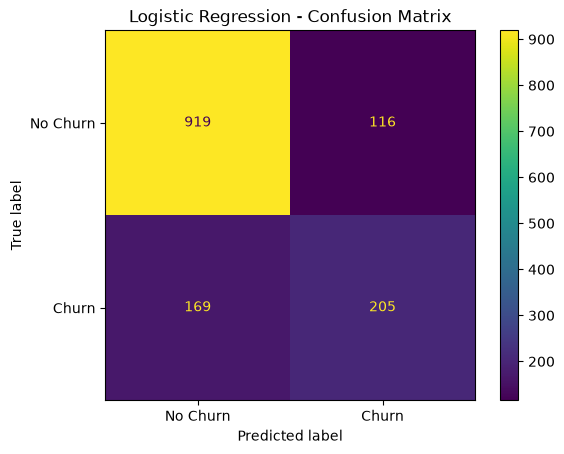

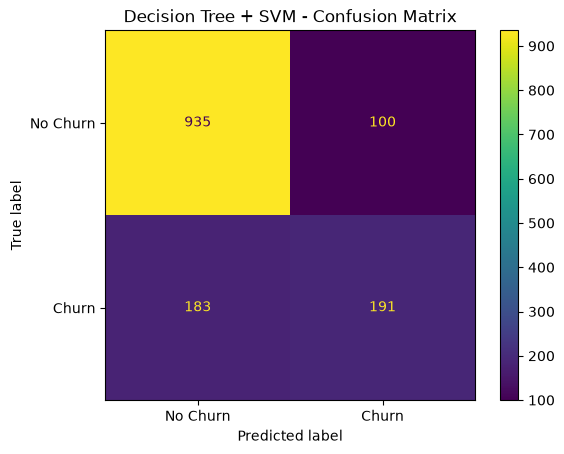

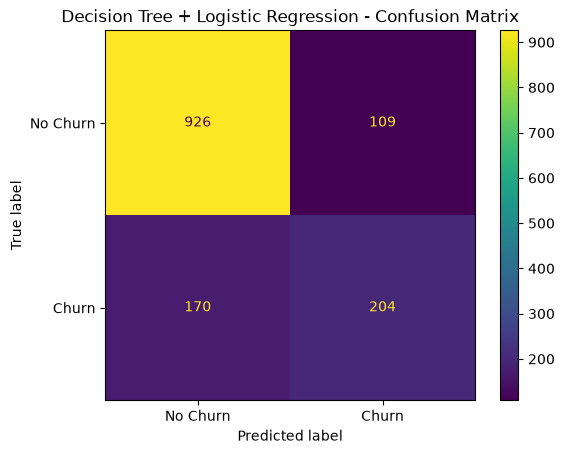

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test_processed)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Churn", "Churn"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [22]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.797729,0.638629,0.548128,0.589928,0.845672
1,Decision Tree + SVM,0.799148,0.656357,0.510695,0.574436,0.844605
2,Decision Tree + Logistic Regression,0.801987,0.651757,0.545455,0.593886,0.851949


In [23]:
from sklearn.metrics import brier_score_loss, log_loss

probability_results = []

for name, model in models.items():
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    probability_results.append({
        "Model": name,
        "Brier Score": brier_score_loss(y_test, y_prob),
        "Log Loss": log_loss(y_test, y_prob)
    })

probability_df = pd.DataFrame(probability_results)

probability_df

,Model,Brier Score,Log Loss
0,Logistic Regression,0.137120,0.415893
1,Decision Tree + SVM,0.136644,0.422883
2,Decision Tree + Logistic Regression,0.134238,0.406405


In [24]:
y_prob_dt_lr = dt_lr.predict_proba(X_test_processed)[:, 1]

probability_check = pd.DataFrame({
    "Actual": y_test.values,
    "Churn Probability": y_prob_dt_lr
})

probability_check.head(20)

,Actual,Churn Probability
0,0,0.056005
1,0,0.668736
2,0,0.063869
3,0,0.530992
4,0,0.030839
5,0,0.499904
6,0,0.469073
7,0,0.075345
8,0,0.001228
9,1,0.408512


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

dt_lr_cv = VotingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )),
        ("lr", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ],
    voting="soft"
)

In [27]:
from sklearn.pipeline import Pipeline

dt_lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dt_lr_cv)
])

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    dt_lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "brier": "neg_brier_score",
        "log_loss": "neg_log_loss"
    },
    n_jobs=-1
)

In [29]:
import numpy as np
import pandas as pd

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Brier Score",
        "Log Loss"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
        -cv_results["test_brier"].mean(),
        -cv_results["test_log_loss"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_brier"].std(),
        cv_results["test_log_loss"].std()
    ]
})

cv_summary

,Metric,Mean,Std
0,Accuracy,0.807421,0.013625
1,Precision,0.665555,0.034650
2,Recall,0.554515,0.032728
3,F1,0.604313,0.026722
4,ROC-AUC,0.861316,0.011189
5,Brier Score,0.130042,0.005060
6,Log Loss,0.398202,0.012092


In [31]:
y.value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [32]:
y_prob = dt_lr.predict_proba(X_test_processed)[:, 1]

probability_check = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob,
    "Prediction": (y_prob >= 0.5).astype(int)
})

probability_check.head(20)

,Actual,Probability,Prediction
0,0,0.056005,0
1,0,0.668736,1
2,0,0.063869,0
3,0,0.530992,1
4,0,0.030839,0
5,0,0.499904,0
6,0,0.469073,0
7,0,0.075345,0
8,0,0.001228,0
9,1,0.408512,0


In [33]:
false_negatives = probability_check[
    (probability_check["Actual"] == 1) &
    (probability_check["Probability"] < 0.5)
]

print("False negatives:", len(false_negatives))

False negatives: 170


In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall   :", recall_score(y_test, y_pred_threshold))
    print("F1 Score :", f1_score(y_test, y_pred_threshold))


Threshold: 0.3
Precision: 0.5531914893617021
Recall   : 0.7647058823529411
F1 Score : 0.6419753086419753

Threshold: 0.4
Precision: 0.5890736342042755
Recall   : 0.6631016042780749
F1 Score : 0.6238993710691824

Threshold: 0.5
Precision: 0.6517571884984026
Recall   : 0.5454545454545454
F1 Score : 0.5938864628820961

Threshold: 0.6
Precision: 0.695852534562212
Recall   : 0.4037433155080214
F1 Score : 0.5109983079526227

Threshold: 0.7
Precision: 0.8217821782178217
Recall   : 0.22192513368983957
F1 Score : 0.3494736842105263


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("dt", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),
            ("lr", LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
        ],
        voting="soft"
    ))
])

In [36]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Payment Method','Paperless Billing','Contract',...,'Partner', 'Tenure Months','Monthly Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [37]:
y_prob = final_model.predict_proba(X_test)[:, 1]

In [38]:
y_pred = (y_prob >= 0.5).astype(int)

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    log_loss
)

print("Final Test Results")
print("------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("Brier    :", brier_score_loss(y_test, y_prob))
print("Log Loss :", log_loss(y_test, y_prob))

Final Test Results
------------------
Accuracy : 0.8019872249822569
Precision: 0.6517571884984026
Recall   : 0.5454545454545454
F1 Score : 0.5938864628820961
ROC-AUC  : 0.8519491591102843
Brier    : 0.13423839404769752
Log Loss : 0.4064048618344875


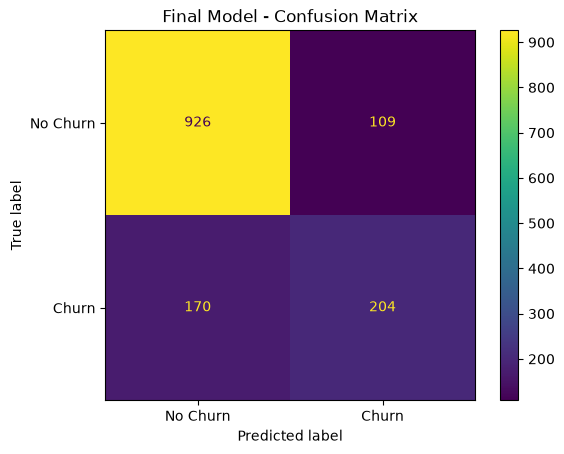

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Final Model - Confusion Matrix")
plt.show()

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

balanced_final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("dt", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),
            ("lr", LogisticRegression(
                max_iter=1000,
                random_state=42,
                class_weight="balanced"
            ))
        ],
        voting="soft"
    ))
])

In [42]:
balanced_final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Payment Method','Paperless Billing','Contract',...,'Partner', 'Tenure Months','Monthly Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [43]:
y_prob_bal = balanced_final_model.predict_proba(X_test)[:, 1]

In [44]:
y_pred_bal = (y_prob_bal >= 0.5).astype(int)

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    log_loss
)

print("Final Test Results for Balanced Final Model")
print("------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1 Score :", f1_score(y_test, y_pred_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_bal))
print("Brier    :", brier_score_loss(y_test, y_prob_bal))
print("Log Loss :", log_loss(y_test, y_prob_bal))


print("\nFinal Test Results for Unbalanced ")
print("------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("Brier    :", brier_score_loss(y_test, y_prob))
print("Log Loss :", log_loss(y_test, y_prob))

Final Test Results for Balanced Final Model
------------------
Accuracy : 0.7842441447835344
Precision: 0.5795454545454546
Recall   : 0.6818181818181818
F1 Score : 0.6265356265356266
ROC-AUC  : 0.8519543258673693
Brier    : 0.14128846382745383
Log Loss : 0.42503715623922866

Final Test Results for Unbalanced 
------------------
Accuracy : 0.8019872249822569
Precision: 0.6517571884984026
Recall   : 0.5454545454545454
F1 Score : 0.5938864628820961
ROC-AUC  : 0.8519491591102843
Brier    : 0.13423839404769752
Log Loss : 0.4064048618344875
